In [1]:
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigvals

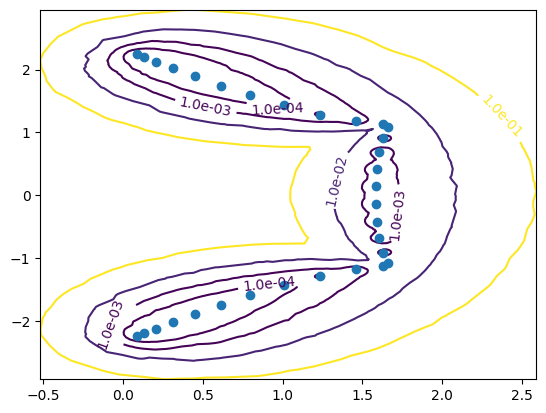

In [2]:
import shapely
from pseudopy import NonnormalAuto, demo #NOTE: had to manually edit this file (pseudopy/normal.py) to import unary_union instead of cascaded_union, which is deprecated
from matplotlib import pyplot
from scipy.linalg import eigvals

# get Grcar matrix
A = demo.grcar(32).todense()

# compute pseudospectrum for the levels of interest between [1e-5, 1]
pseudo = NonnormalAuto(A, 1e-5, 1) #and nonnormal np.Inf -> np.inf

# plot
pseudo.plot([10**k for k in range(-4, 0)], spectrum=eigvals(A))
#also patched in utils.py contours.collections -> contours.get_paths()
"""
and I think need to do something with clabel log format thing in utils.py line 64, 
not sure what yet so to get it to still label for now I just changed it to a diff format
"""
pyplot.show()

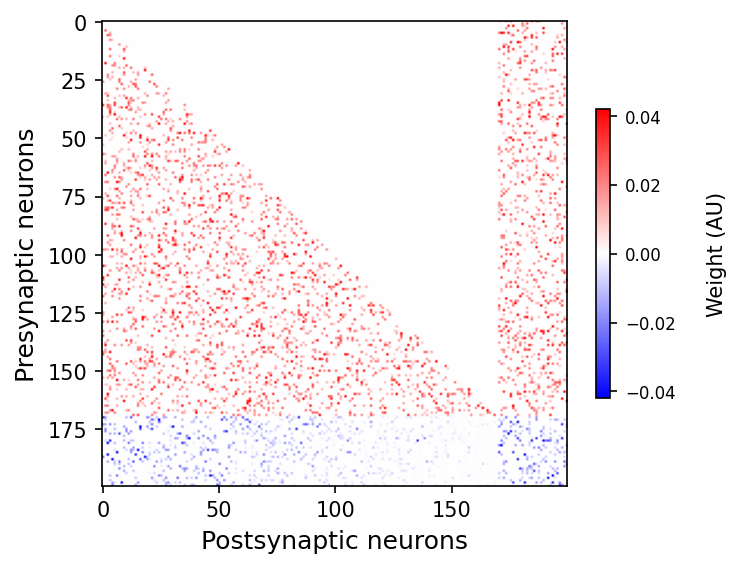

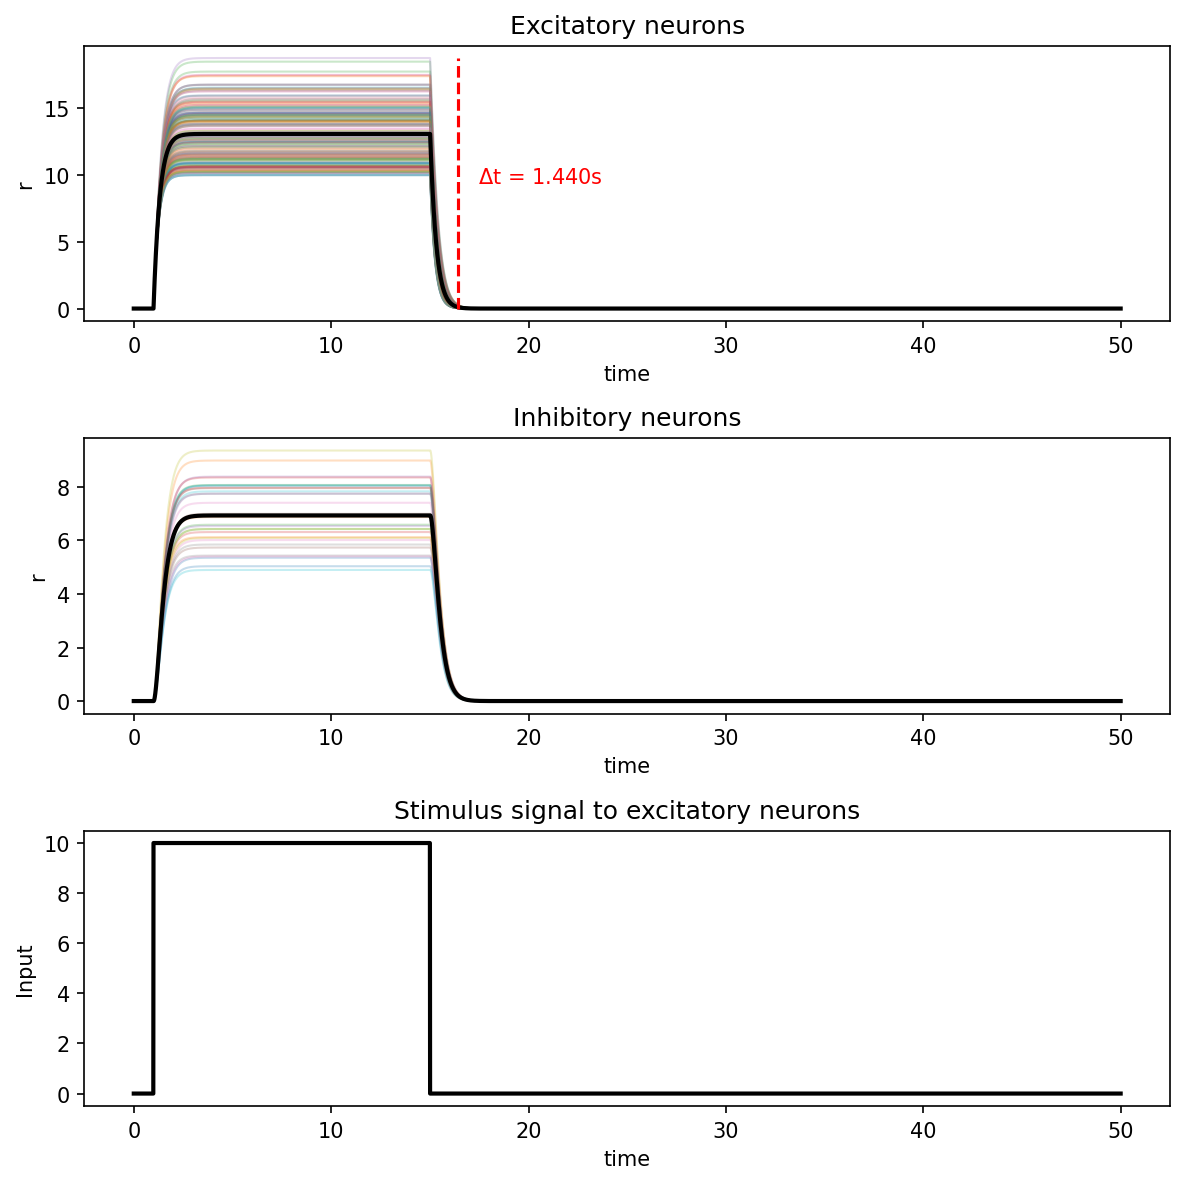

In [3]:
# import sys
# sys.path.append(1, 'AMATH_342_neuronal_circuits-main/')

from AMATH_342_neuronal_circuits_main import Modelling_local_circuits as mlc

random_seed = 0

# Connectivity parameters
g = .002  # overall gain of connectivity
n_neurons = 200 # number of neurons
connectivity_proba = .15 # Likelihood of two neurons to be connected with each other
r_inhibitory = .15 # Ratio of inhibitory neurons
inh_exc_balance = .15 # Result of I/E for every neuron's input

# Simulation parameters 
t_max = 50 # Length of simulation
dt = 0.01 # Simulation time step
t_stimulus_start = 1 # Stimulus start time
t_stimulus_end = 15 # Stimulus end time
stim_strength = 10 # Stimulus strength rate
tau = .25 # Neuron time constant

# Simulation variables
n_steps = int(t_max / dt)
stimulus = mlc.generate_stimulus(n_neurons, n_steps, r_inhibitory, stim_strength, t_stimulus_start, t_stimulus_end, dt)

# Get connectivity matrix
W = mlc.generate_random_connectivity_matrix_FF(n_neurons=n_neurons, r_inhibitory=r_inhibitory, g=g, 
                                           connectivity_proba=connectivity_proba, connectivity_proba_EE=connectivity_proba, 
                                           random_seed=random_seed, inh_exc_balance=inh_exc_balance, make_EE_ff=True)
mlc.plot_matrix(W)

# Run simulation
r = mlc.run_simulation(W, stimulus, dt=dt)

# Plot
mlc.plot_time_series(r, stimulus, dt, r_inhibitory)

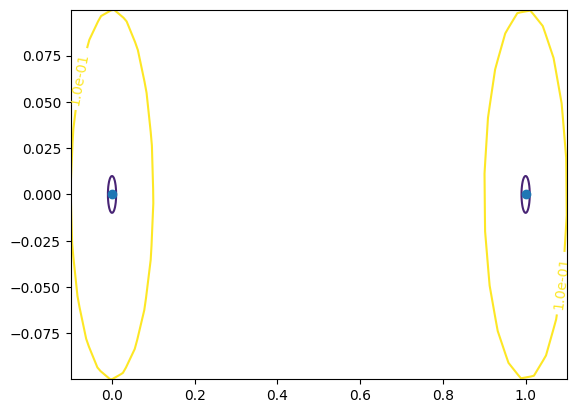

In [4]:
W1 = np.array([[.5,.5],[.5,.5]])
pseudoW1 = NonnormalAuto(W1, 1e-5, 1) #and nonnormal np.Inf -> np.inf
pseudoW1.plot([10**k for k in range(-4, 0)], spectrum=eigvals(W1))

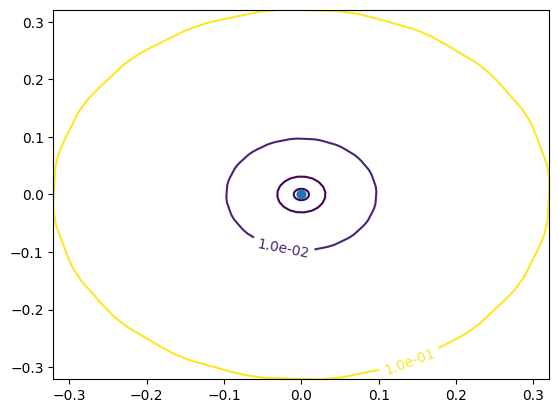

In [5]:
W2 = np.array([[.5,.5],[-.5,-.5]])
pseudoW2 = NonnormalAuto(W2, 1e-5, 1) #and nonnormal np.Inf -> np.inf
pseudoW2.plot([10**k for k in range(-4, 0)], spectrum=eigvals(W2))

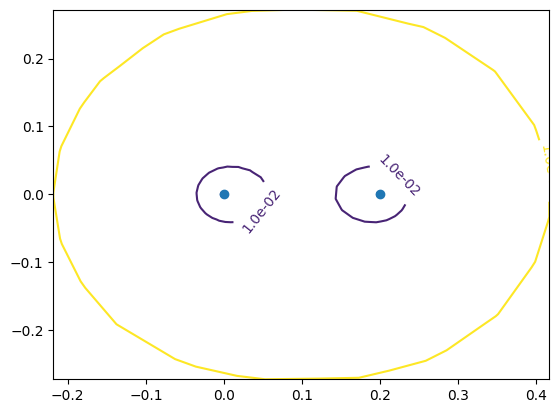

In [6]:
W3 = np.array([[.5,.5],[-.3,-.3]])
pseudoW3 = NonnormalAuto(W3, 1e-5, 1) #and nonnormal np.Inf -> np.inf
pseudoW3.plot([10**k for k in range(-4, 0)], spectrum=eigvals(W3))

In [7]:
np.linalg.matrix_rank(W)
W.shape

(200, 200)

In [8]:
pseudoW = NonnormalAuto(W, 1e-2, 1) #and nonnormal np.Inf -> np.inf

# plot
pseudoW.plot([10**k for k in range(-4, 0)], spectrum=eigvals(W))
#also patched in utils.py contours.collections -> contours.get_paths()
"""
and I think need to do something with clabel log format thing in utils.py line 64, 
not sure what yet so to get it to still label for now I just changed it to a diff format
"""
pyplot.show()

LinAlgError: singular matrix: resolution failed at diagonal 0